# Analyse exploratoire — traces d’utilisation de Copilote

**Objectif :** comprendre les sessions du jeu d'entraînement et identifier des caractéristiques utiles pour reconnaître l'utilisateur.

Sources locales : `data/train.csv`, `BE_CS1_indications.ipynb` et `notes`. Une ligne représente une session : identifiant utilisateur (cible), navigateur, puis une séquence de longueur variable. Le fichier n'a pas d'en-tête. Les jetons `tXX` sont des marqueurs temporels, pas des actions.

Exécuter les cellules dans l'ordre. Dépendances : `pandas`, `numpy`, `matplotlib`, `seaborn`, `ipykernel`. L'analyse conserve toutes les sessions et ne modifie pas les données sources.

In [1]:
from pathlib import Path
from collections import Counter
import csv
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 20)
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


Python 3.13.7 | pandas 2.3.2 | numpy 2.3.3


## 1. Chargement et aperçu

On lit chaque ligne avec `csv.reader` et conserve sa séquence sous forme de liste. Une lecture rectangulaire créerait de nombreuses cases vides uniquement parce que les sessions n'ont pas la même longueur.

In [2]:
candidats = [Path("data/train.csv"), Path("be1/data/train.csv")]
DATA_PATH = next((p for p in candidats if p.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Ouvrir le notebook depuis be1 ou son dossier parent.")

records, lignes_invalides = [], []
with DATA_PATH.open(encoding="utf-8-sig", newline="") as fichier:
    for ligne, row in enumerate(csv.reader(fichier), start=1):
        if len(row) < 2:
            lignes_invalides.append(ligne)
        else:
            records.append({"ligne": ligne, "utilisateur": row[0],
                            "navigateur": row[1], "tokens": row[2:]})
if lignes_invalides:
    raise ValueError(f"Lignes mal formées à examiner : {lignes_invalides[:10]}")
sessions = pd.DataFrame(records)
assert not sessions.empty, "Le fichier est vide."
apercu = sessions[["ligne", "utilisateur", "navigateur"]].copy()
apercu["nb_tokens"] = sessions.tokens.map(len)
apercu["debut_sequence"] = sessions.tokens.map(lambda x: x[:5])
display(apercu.head())
display(pd.Series({"Sessions": len(sessions),
                   "Utilisateurs": sessions.utilisateur.nunique(),
                   "Navigateurs": sessions.navigateur.nunique(),
                   "Jetons": apercu.nb_tokens.sum()}, name="Effectif").to_frame())

,ligne,utilisateur,navigateur,nb_tokens,debut_sequence
0,1,nuh,Firefox,3128,"[Création d'un écran(infologic.core.accueil.AccueilController), Affichage d'une dialog..."
1,2,muz,Google Chrome,136,"[Création d'un écran(infologic.core.gui.controllers.BlankController), Création d'un éc..."
2,3,zrx,Microsoft Edge,766,[Affichage d'une dialogue(infologic.core.gui.controllers.BlankController)<ACCUEIL_INST...
3,4,pou,Firefox,1199,"[Création d'un écran(infologic.core.gui.controllers.nested.InputFormNestedWindow), t5,..."
4,5,ald,Google Chrome,233,[Affichage d'une dialogue(infologic.acti.modules.AT_ACTIVITES.compterendu.CompteRenduF...


,Effectif
Sessions,3279
Utilisateurs,247
Navigateurs,4
Jetons,2787933


## 2. Qualité des données

On distingue les champs réellement vides des absences dues à une séquence courte. On recherche aussi les sessions identiques, avec ou sans la cible. Des traces identiques présentes dans l'entraînement et la validation pourraient rendre l'évaluation trop optimiste.

In [3]:
# Tuple exact : on préserve l'ordre des actions et tous les marqueurs.
signatures = pd.Series(list(zip(sessions.navigateur, sessions.tokens.map(tuple))), index=sessions.index)
sessions["groupe_trace"] = pd.factorize(signatures)[0]
conflits = sessions.groupby("groupe_trace").utilisateur.nunique()
qualite = pd.Series({
    "Utilisateurs vides": sessions.utilisateur.str.strip().eq("").sum(),
    "Navigateurs vides": sessions.navigateur.str.strip().eq("").sum(),
    "Séquences vides": sessions.tokens.map(len).eq(0).sum(),
    "Jetons vides ou blancs": sum(not t.strip() for seq in sessions.tokens for t in seq),
    "Doublons exacts supplémentaires (cible incluse)": sessions.duplicated(["utilisateur", "groupe_trace"]).sum(),
    "Doublons de traces supplémentaires (hors cible)": sessions.groupe_trace.duplicated().sum(),
    "Groupes de traces avec plusieurs utilisateurs": conflits.gt(1).sum(),
}, name="Nombre")
display(qualite.to_frame())

,Nombre
Utilisateurs vides,0
Navigateurs vides,0
Séquences vides,0
Jetons vides ou blancs,0
Doublons exacts supplémentaires (cible incluse),0
Doublons de traces supplémentaires (hors cible),0
Groupes de traces avec plusieurs utilisateurs,0


## 3. Répartition de la cible et des navigateurs

Le nombre de sessions par utilisateur indique si certaines classes sont peu représentées. La fréquence de la classe majoritaire donne un repère descriptif pour l'accuracy, sans constituer une évaluation sur validation.

,Sessions par utilisateur
count,247.000000
mean,13.275304
std,8.862380
min,4.000000
25%,7.000000
50%,12.000000
75%,16.000000
max,75.000000


,Valeur
Classes avec une seule session,0.000000
Classes avec moins de 5 sessions,10.000000
Part de la classe majoritaire (%),2.287283


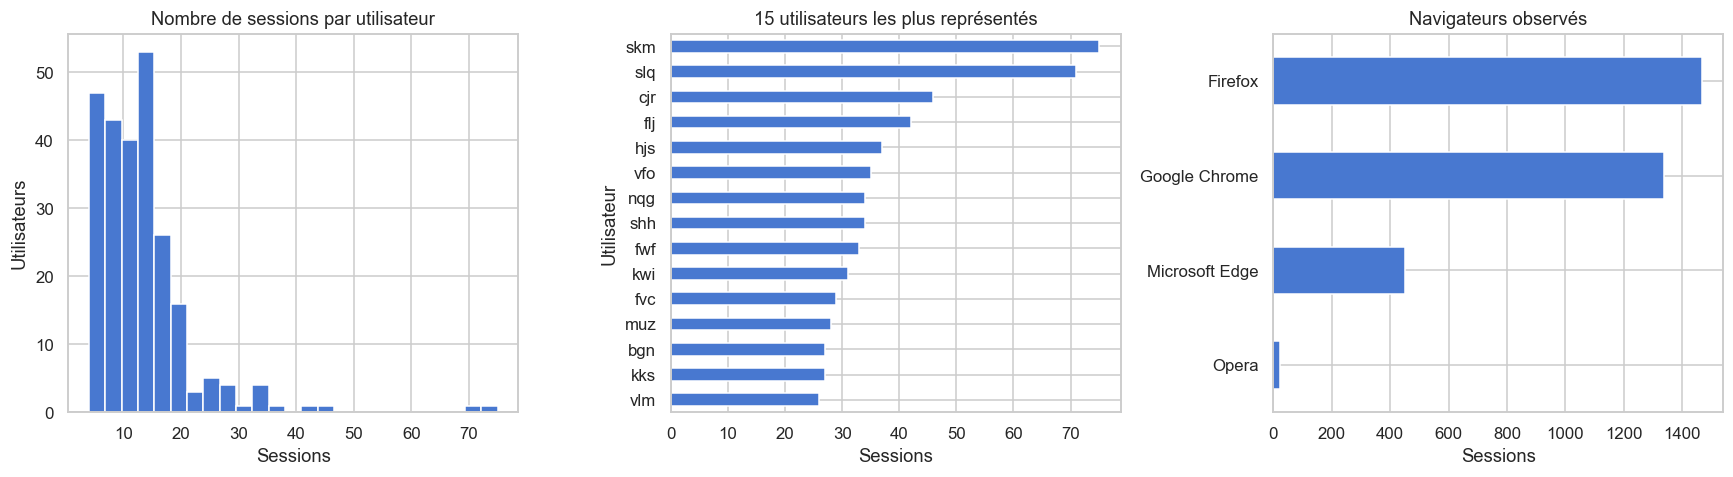

,sessions,part_pct
navigateur,,
Firefox,1466,44.71
Google Chrome,1339,40.84
Microsoft Edge,451,13.75
Opera,23,0.70


In [4]:
effectifs = sessions.utilisateur.value_counts()
navigateurs = sessions.navigateur.value_counts()
display(effectifs.describe().to_frame("Sessions par utilisateur"))
display(pd.Series({"Classes avec une seule session": effectifs.eq(1).sum(),
                   "Classes avec moins de 5 sessions": effectifs.lt(5).sum(),
                   "Part de la classe majoritaire (%)": 100 * effectifs.max() / len(sessions)},
                  name="Valeur").to_frame())
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(effectifs, bins=25)
axes[0].set(title="Nombre de sessions par utilisateur", xlabel="Sessions", ylabel="Utilisateurs")
effectifs.head(15).sort_values().plot.barh(ax=axes[1])
axes[1].set(title="15 utilisateurs les plus représentés", xlabel="Sessions", ylabel="Utilisateur")
navigateurs.sort_values().plot.barh(ax=axes[2])
axes[2].set(title="Navigateurs observés", xlabel="Sessions", ylabel="")
plt.tight_layout()
plt.show()
display(pd.DataFrame({"sessions": navigateurs, "part_pct": 100 * navigateurs / len(sessions)}).round(2))

,Utilisateurs
Navigateurs distincts par utilisateur,
1,247


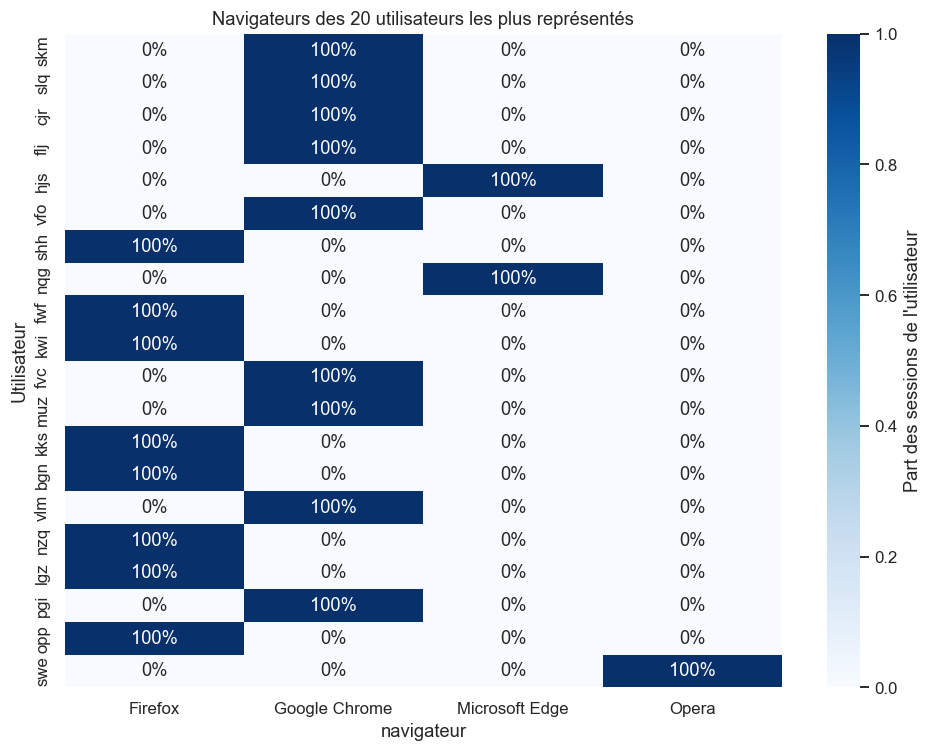

In [5]:
croisement = pd.crosstab(sessions.utilisateur, sessions.navigateur)
parts_navigateurs = croisement.div(croisement.sum(axis=1), axis=0)
display(croisement.gt(0).sum(axis=1).value_counts().sort_index()
        .rename_axis("Navigateurs distincts par utilisateur").to_frame("Utilisateurs"))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(parts_navigateurs.loc[effectifs.head(20).index], cmap="Blues", vmin=0, vmax=1,
            annot=True, fmt=".0%", ax=ax, cbar_kws={"label": "Part des sessions de l'utilisateur"})
ax.set(title="Navigateurs des 20 utilisateurs les plus représentés", ylabel="Utilisateur")
plt.tight_layout()
plt.show()

**Lecture :** le navigateur peut aider à caractériser les habitudes, mais plusieurs utilisateurs le partagent. La carte présente seulement les 20 classes les plus fréquentes ; elle ne représente pas toutes les classes.

## 4. Extraction de caractéristiques descriptives

On sépare strictement les jetons correspondant à `t` suivi de chiffres. Pour les actions, on extrait le type (avant `(`, `<` ou `$`), l'écran, la configuration et la chaîne métier. Le suffixe `1` est isolé comme indicateur de modification conformément aux notes ; cette règle reste une convention de parsing à confirmer avec la documentation métier.

Les écrans sont mentionnés lors de certains événements seulement : leur absence dans un jeton n'est donc pas nécessairement une donnée manquante. On compte les écrans **explicitement mentionnés**, sans inventer les valeurs absentes.

In [6]:
temps_re = re.compile(r"t(\d+)")
ecran_re = re.compile(r"\((.*?)\)")
config_re = re.compile(r"<(.*?)>")
chaine_re = re.compile(r"\$(.*?)\$")

def extraire_session(tokens):
    actions, temps, ecrans, configs, chaines = [], [], [], [], []
    modifications = 0
    for token in tokens:
        if not token.strip():
            continue
        match = temps_re.fullmatch(token)
        if match:
            temps.append(int(match.group(1)))
            continue
        type_action = re.split(r"[<($]", token, maxsplit=1)[0].strip()
        actions.append(re.sub(r"1$", "", type_action).strip())
        modifications += int(token.endswith("1"))
        ecrans.extend(ecran_re.findall(token))
        configs.extend(config_re.findall(token))
        chaines.extend(chaine_re.findall(token))
    return {
        "nb_tokens": len(tokens), "nb_actions": len(actions),
        "nb_types_actions": len(set(actions)), "nb_marqueurs": len(temps),
        "repere_max": max(temps) if temps else np.nan,
        "retours_temps": sum(b < a for a, b in zip(temps, temps[1:])),
        "repetitions_temps": sum(b == a for a, b in zip(temps, temps[1:])),
        "nb_ecrans": len(set(ecrans)), "nb_configs": len(set(configs)),
        "nb_chaines": len(set(chaines)),
        "part_modification": modifications / len(actions) if actions else np.nan,
        "actions": actions, "ecrans": ecrans, "chaines": chaines,
    }

descriptions = pd.DataFrame(sessions.tokens.map(extraire_session).tolist(), index=sessions.index)
features = pd.concat([sessions[["ligne", "utilisateur", "navigateur", "groupe_trace"]],
                      descriptions.drop(columns=["actions", "ecrans", "chaines"])], axis=1)
display(features.head())

,ligne,utilisateur,navigateur,groupe_trace,nb_tokens,nb_actions,nb_types_actions,nb_marqueurs,repere_max,retours_temps,repetitions_temps,nb_ecrans,nb_configs,nb_chaines,part_modification
0,1,nuh,Firefox,0,3128,2514,19,614,2905,0,33,7,3,2,0.001591
1,2,muz,Google Chrome,1,136,90,11,46,230,0,0,5,2,2,0.288889
2,3,zrx,Microsoft Edge,2,766,608,21,158,750,0,8,17,7,2,0.082237
3,4,pou,Firefox,3,1199,886,19,313,1445,0,24,10,4,1,0.072235
4,5,ald,Google Chrome,4,233,173,14,60,275,0,5,8,4,2,0.011561


## 5. Longueur, diversité et sessions extrêmes

Les histogrammes en `log(1 + x)` rendent visibles les sessions courtes et longues sur une même figure, sans supprimer les extrêmes. Le seuil du 99e percentile sert uniquement à repérer les grandes sessions.

,count,mean,std,min,50%,90%,95%,99%,max
nb_tokens,3279.0,850.24,1212.32,2.0,423.00,2077.00,2900.20,5658.62,14468.00
nb_actions,3279.0,692.36,1005.87,0.0,340.00,1707.20,2386.90,4697.20,11977.00
nb_types_actions,3279.0,17.00,4.32,0.0,17.00,23.00,24.00,26.00,29.00
nb_marqueurs,3279.0,157.88,212.51,1.0,82.00,383.00,540.20,945.52,2491.00
nb_ecrans,3279.0,10.72,5.84,0.0,9.00,19.00,22.00,29.00,42.00
nb_configs,3279.0,5.02,3.13,0.0,4.00,9.00,11.00,14.00,24.00
nb_chaines,3279.0,2.22,2.78,0.0,1.00,6.00,8.00,12.00,23.00
part_modification,3278.0,0.16,0.19,0.0,0.09,0.42,0.58,0.82,0.91


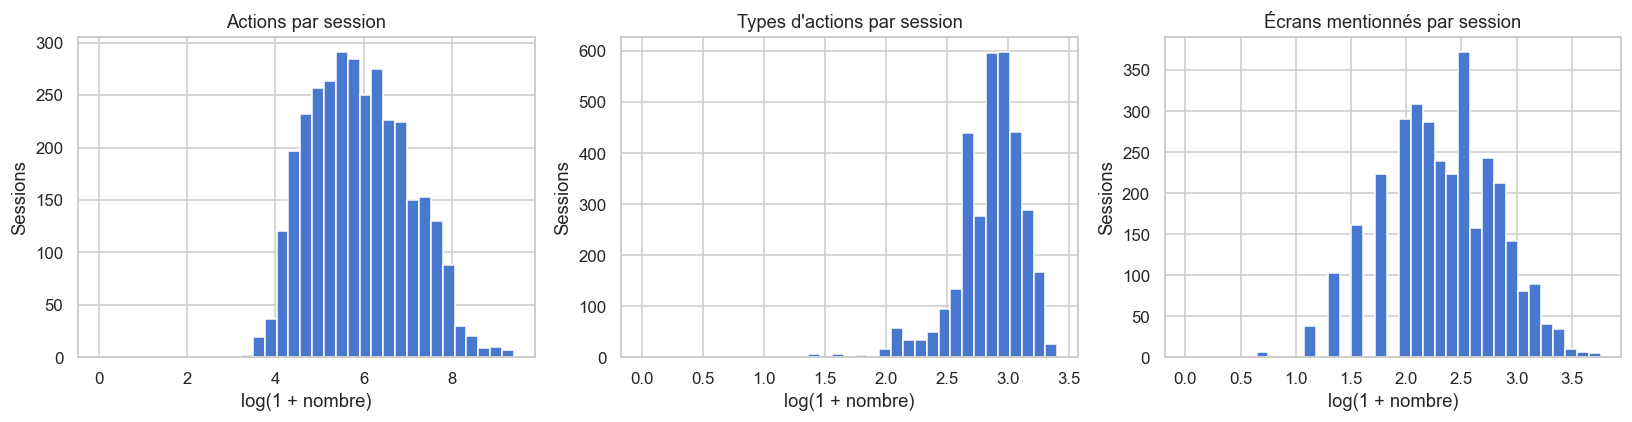

,ligne,utilisateur,navigateur,nb_actions,nb_ecrans,nb_marqueurs
3082,3083,wvy,Firefox,11977,23,2491
3234,3235,fxg,Firefox,11505,18,1938
84,85,urs,Google Chrome,10625,16,1649
2812,2813,wvy,Firefox,9707,17,2249
2520,2521,fjb,Microsoft Edge,9430,33,1845
1022,1023,zct,Google Chrome,9370,23,1313
817,818,ckl,Microsoft Edge,9204,42,1709
3247,3248,fjb,Microsoft Edge,8833,32,1681
2814,2815,fxg,Firefox,8476,18,1582
283,284,tmn,Firefox,8466,29,2154


Le 99e percentile est de **4,697 actions**. **33 sessions** le dépassent. Une grande session peut être légitime : aucun retrait automatique n'est appliqué.

In [7]:
numeriques = ["nb_tokens", "nb_actions", "nb_types_actions", "nb_marqueurs",
              "nb_ecrans", "nb_configs", "nb_chaines", "part_modification"]
display(features[numeriques].describe(percentiles=[.5, .9, .95, .99]).T.round(2))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titre in zip(axes, ["nb_actions", "nb_types_actions", "nb_ecrans"],
                           ["Actions par session", "Types d'actions par session", "Écrans mentionnés par session"]):
    ax.hist(np.log1p(features[col]), bins=35)
    ax.set(title=titre, xlabel="log(1 + nombre)", ylabel="Sessions")
plt.tight_layout()
plt.show()
seuil = features.nb_actions.quantile(.99)
display(features.nlargest(10, "nb_actions")[["ligne", "utilisateur", "navigateur", "nb_actions", "nb_ecrans", "nb_marqueurs"]])
display(Markdown(f"Le 99e percentile est de **{seuil:,.0f} actions**. "
                 f"**{features.nb_actions.gt(seuil).sum()} sessions** le dépassent. "
                 "Une grande session peut être légitime : aucun retrait automatique n'est appliqué."))

## 6. Vérification des marqueurs temporels

Les indications évoquent des intervalles de cinq secondes et les notes montrent `t5`, `t10`, `t15`. On vérifie l'ordre des valeurs. `repere_max` désigne uniquement la valeur maximale observée : ce n'est pas une durée validée. Additionner les valeurs ou multiplier aveuglément leur nombre par cinq serait ambigu si le compteur se répète ou recommence.

In [8]:
display(pd.Series({
    "Sessions sans marqueur": features.nb_marqueurs.eq(0).sum(),
    "Sessions avec retour à une valeur inférieure": features.retours_temps.gt(0).sum(),
    "Sessions avec marqueurs consécutifs de même valeur": features.repetitions_temps.gt(0).sum(),
    "Nombre total de retours": features.retours_temps.sum(),
}, name="Nombre").to_frame())
display(features.loc[features.retours_temps.gt(0),
                     ["ligne", "nb_marqueurs", "repere_max", "retours_temps"]].head())
indices = features.index[features.retours_temps.gt(0)]
if len(indices):
    seq = [t for t in sessions.loc[indices[0], "tokens"] if temps_re.fullmatch(t)]
    rupture = next(i for i in range(1, len(seq)) if int(seq[i][1:]) < int(seq[i-1][1:]))
    print("Exemple autour d'un retour du compteur :", seq[max(0, rupture-3):rupture+4])

,Nombre
Sessions sans marqueur,0
Sessions avec retour à une valeur inférieure,0
Sessions avec marqueurs consécutifs de même valeur,2158
Nombre total de retours,0


,ligne,nb_marqueurs,repere_max,retours_temps


## 7. Actions, écrans et chaînes les plus fréquents

Deux mesures complémentaires : le nombre total d'occurrences (sensible aux sessions longues) et la proportion de sessions contenant au moins une fois l'élément.

,occurrences,sessions,sessions_pct
Exécution d'un bouton,510645,3275,99.88
Saisie dans un champ,265633,3206,97.77
Sélection d'un écran,206813,3026,92.28
Fermeture d'une dialogue,171026,3223,98.29
Affichage d'une dialogue,168928,3219,98.17
Lancement d'une action générique,115283,2906,88.62
Sélection d’un onglet,109209,2714,82.77
Raccourci,82176,1944,59.29
Création d'un écran,76930,3134,95.58
Chainage,68194,2883,87.92


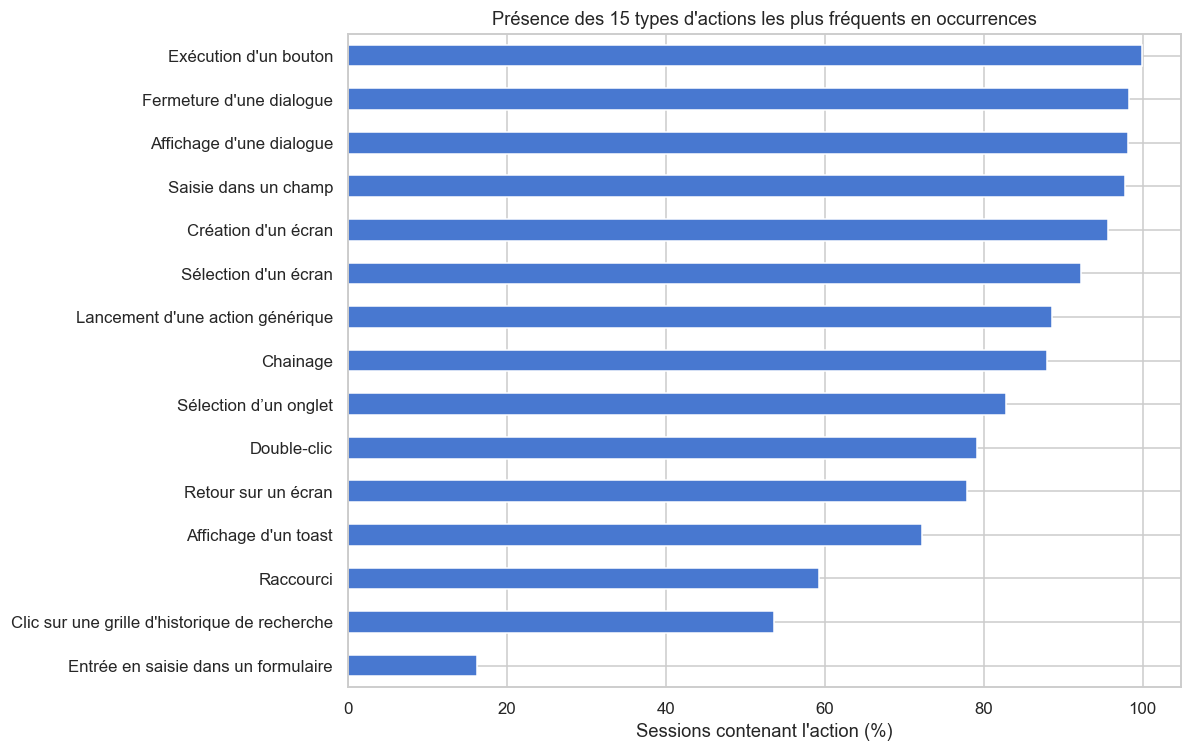

**Ecrans :** 418 valeurs distinctes mentionnées.

,occurrences,sessions,sessions_pct
MAINT,37932,1726,52.64
infologic.core.gui.controllers.BlankController,33615,2098,63.98
infologic.core.FichiersController,18425,1592,48.55
infologic.crm.modules.CRM_PLANNING.planning.PlanningController,17564,2091,63.77
DEV,15759,1133,34.55
infologic.infoc.statmodif.fichierbase.StatFBController,15006,978,29.83
infologic.core.gui.controllers.nested.InputFormNestedWindow,9936,2623,79.99
infologic.orga.modules.OR_FICHIERTRAVAIL.InstanceForm,9907,1596,48.67
infologic.core.accueil.AccueilController,8484,1415,43.15
infologic.core.gui.controllers.nested.homeview.InputFormHomeView,8438,1484,45.26


**Chaines :** 76 valeurs distinctes mentionnées.

,occurrences,sessions,sessions_pct
VT,53480,565,17.23
GP,39424,503,15.34
EDI,33359,567,17.29
TEC,26315,519,15.83
OT,24509,591,18.02
SV,23681,497,15.16
GESCO,22173,503,15.34
JCP,21653,283,8.63
ST,17160,401,12.23
WEB,11410,319,9.73


In [9]:
def frequences(colonne):
    occurrences = Counter(x for seq in descriptions[colonne] for x in seq)
    presence = Counter(x for seq in descriptions[colonne] for x in set(seq))
    table = pd.DataFrame({"occurrences": pd.Series(occurrences), "sessions": pd.Series(presence)})
    table["sessions_pct"] = 100 * table.sessions / len(sessions)
    return table.sort_values("occurrences", ascending=False)

freq_actions = frequences("actions")
display(freq_actions.head(20).round(2))
fig, ax = plt.subplots(figsize=(11, 7))
freq_actions.head(15).sort_values("sessions_pct").sessions_pct.plot.barh(ax=ax)
ax.set(title="Présence des 15 types d'actions les plus fréquents en occurrences",
       xlabel="Sessions contenant l'action (%)", ylabel="")
plt.tight_layout()
plt.show()
for colonne in ["ecrans", "chaines"]:
    display(Markdown(f"**{colonne.capitalize()} :** {len(frequences(colonne))} valeurs distinctes mentionnées."))
    display(frequences(colonne).head(10).round(2))

## 8. Comparaisons entre utilisateurs et corrélations

On compare les huit classes les plus représentées et les corrélations de Spearman entre caractéristiques numériques. Les identifiants utilisateurs ne sont pas des mesures numériques : les corréler après encodage n'aurait pas de sens.

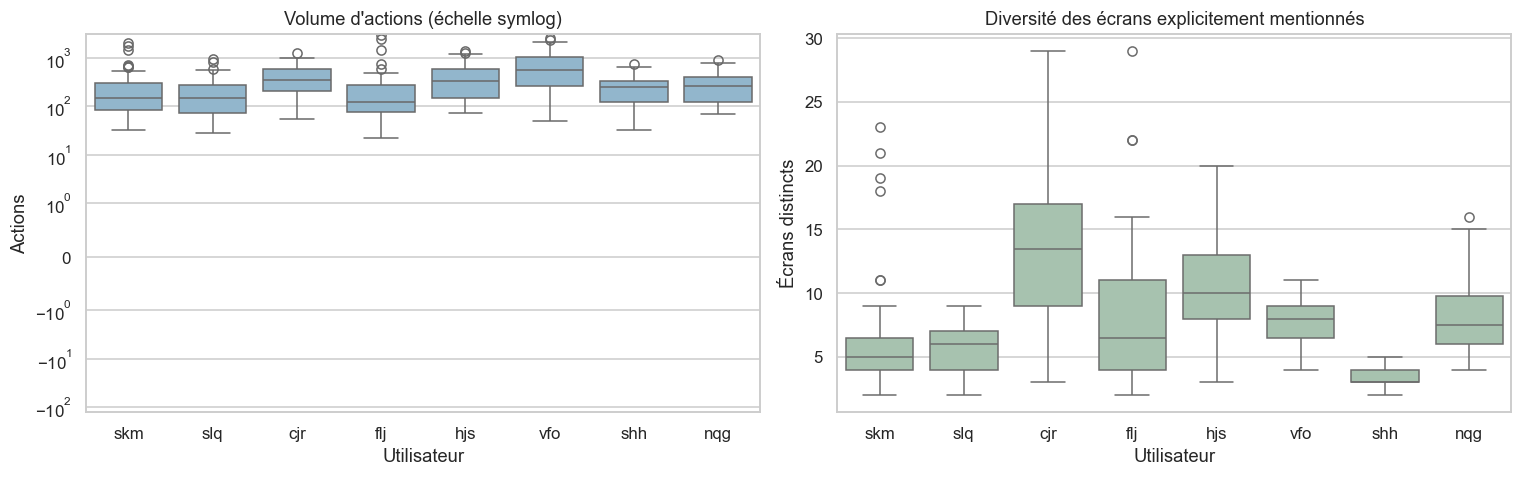

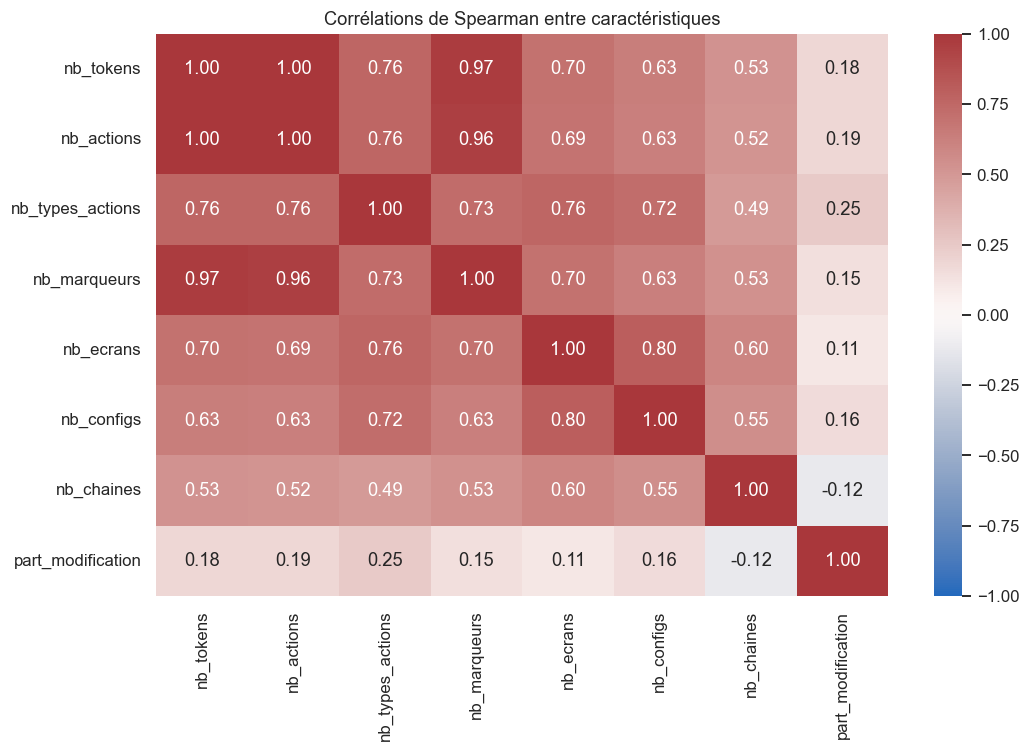

In [10]:
selection = effectifs.head(8).index
sous_ensemble = features[features.utilisateur.isin(selection)]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=sous_ensemble, x="utilisateur", y="nb_actions", order=selection, ax=axes[0], color="#88b9d6")
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set(title="Volume d'actions (échelle symlog)", xlabel="Utilisateur", ylabel="Actions")
sns.boxplot(data=sous_ensemble, x="utilisateur", y="nb_ecrans", order=selection, ax=axes[1], color="#a2c7ad")
axes[1].set(title="Diversité des écrans explicitement mentionnés", xlabel="Utilisateur", ylabel="Écrans distincts")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(features[numeriques].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="vlag", vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title("Corrélations de Spearman entre caractéristiques")
plt.tight_layout()
plt.show()

**Interprétation :** une différence de médiane peut suggérer une caractéristique utile, mais le recouvrement des distributions limite son pouvoir de séparation. Une corrélation élevée signale une possible redondance ; elle ne mesure pas directement l'utilité pour prédire la cible. Ces comparaisons sont exploratoires et ne prouvent aucune performance de généralisation.

## 9. Bilan et pistes pour la modélisation

In [11]:
display(Markdown(f"""
- **Structure :** {len(sessions):,} sessions, {len(effectifs)} utilisateurs et {len(navigateurs)} navigateurs.
- **Cible :** entre {effectifs.min()} et {effectifs.max()} sessions par utilisateur ; {effectifs.lt(5).sum()} classes ont moins de cinq observations. La classe majoritaire représente {effectifs.max()/len(sessions):.2%} du jeu.
- **Volume :** médiane de {features.nb_actions.median():,.0f} actions, maximum de {features.nb_actions.max():,}. Les sessions extrêmes restent à examiner avant tout nettoyage.
- **Qualité :** {sessions.duplicated(['utilisateur', 'groupe_trace']).sum()} doublons exacts supplémentaires ; {conflits.gt(1).sum()} groupes de traces associés à plusieurs utilisateurs.
- **Temps :** {features.retours_temps.gt(0).sum()} sessions présentent un retour du compteur. La durée réelle n'est pas calculée tant que sa sémantique n'est pas confirmée.
"""))


- **Structure :** 3,279 sessions, 247 utilisateurs et 4 navigateurs.
- **Cible :** entre 4 et 75 sessions par utilisateur ; 10 classes ont moins de cinq observations. La classe majoritaire représente 2.29% du jeu.
- **Volume :** médiane de 340 actions, maximum de 11,977. Les sessions extrêmes restent à examiner avant tout nettoyage.
- **Qualité :** 0 doublons exacts supplémentaires ; 0 groupes de traces associés à plusieurs utilisateurs.
- **Temps :** 0 sessions présentent un retour du compteur. La durée réelle n'est pas calculée tant que sa sémantique n'est pas confirmée.


Pour la suite :

1. Tester le navigateur, les volumes, la diversité des actions et les fréquences normalisées des actions, écrans et chaînes. Comparer les comptes bruts et les proportions pour limiter l'influence des longues sessions.
2. Préparer une validation stratifiée lorsque les effectifs le permettent, en gardant les traces identiques dans le même groupe. Vérifier la présence de chaque classe dans l'entraînement ; les classes très rares demandent un traitement explicite.
3. Ajuster les vocabulaires, transformations, seuils de nettoyage et normalisations uniquement sur la partie entraînement de chaque découpage.
4. Comparer l'accuracy et le F1 macro, afin de ne pas masquer les difficultés des classes peu représentées. Ces métriques seront calculées lors de la modélisation.

Cette exploration utilise tout `train.csv`. Une future validation interne devra être interprétée en tenant compte des choix inspirés par cette exploration. Les données de test ne sont pas utilisées ici.